In [1]:
# draw a jet image centered at (0, 0)
# A "jet image" is a 2D histogram in the (eta, phi) plane,
# weighted by pT. Each event becomes a pixelated image.
#
# Preprocessing:
#   1. Compute pT-weighted centroid of particles in (eta, phi)
#   2. Shift all particles so centroid is at (0, 0)
#   3. Bin into a 2D grid → "image"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm



In [2]:

sig_df = pd.read_csv('data/CoLBTHydro.csv', header=None)
bkg_df = pd.read_csv('data/Jewel.csv', header=None)

MAX_PARTICLES = 50
N_FEAT_PER_PARTICLE = 4        # pT, eta, phi, flag
OBJ_START = 8                  # Column where per-particle data begins



In [3]:

def parse_particles(df, max_particles=MAX_PARTICLES):
    """
    Parse raw CSV into per-particle arrays.
    
    Returns:
    --------
    pt_array : (n_events, max_particles) — transverse momentum
    eta_array : (n_events, max_particles) — pseudorapidity
    phi_array : (n_events, max_particles) — azimuthal angle
    mask : (n_events, max_particles) — 1 for real particles, 0 for padding
    """
    raw = df.values
    n_events = len(df)
    
    pt_array = np.zeros((n_events, max_particles))
    eta_array = np.zeros((n_events, max_particles))
    phi_array = np.zeros((n_events, max_particles))
    mask = np.zeros((n_events, max_particles))
    
    for i in range(n_events):
        n_obj = int(raw[i, 0])                             # Number of particles
        n_obj = min(n_obj, max_particles)                  # Cap at maximum
        
        for j in range(n_obj):
            col_start = OBJ_START + j * N_FEAT_PER_PARTICLE
            col_end = col_start + N_FEAT_PER_PARTICLE
            if col_end <= raw.shape[1]:
                pt_array[i, j] = raw[i, col_start]         # pT
                eta_array[i, j] = raw[i, col_start + 1]    # eta
                phi_array[i, j] = raw[i, col_start + 2]    # phi
                mask[i, j] = 1.0
    
    return pt_array, eta_array, phi_array, mask


# Parse signal and background
sig_pt, sig_eta, sig_phi, sig_mask = parse_particles(sig_df)
bkg_pt, bkg_eta, bkg_phi, bkg_mask = parse_particles(bkg_df)

print(f"Signal events: {sig_pt.shape[0]}")
print(f"Background events: {bkg_pt.shape[0]}")


Signal events: 45208
Background events: 109817


In [5]:
# Compute pT-weighted centroid and shift all particles - Pre-processing 

def center_jet(pt, eta, phi, mask):
    """
    Center each jet so its pT-weighted centroid is at (eta, phi) = (0, 0).
    
    Parameters:
    -----------
    pt : (n_events, max_particles)
    eta : (n_events, max_particles)
    phi : (n_events, max_particles)
    mask : (n_events, max_particles)
    
    Returns:
    --------
    delta_eta : (n_events, max_particles) — centered eta
    delta_phi : (n_events, max_particles) — centered phi
    """
    # Masked pT (zero out padding)
    pt_masked = pt * mask                                  # (n_events, N)
    
    # Total pT per event (avoid division by zero)
    pt_sum = pt_masked.sum(axis=1, keepdims=True)          # (n_events, 1)
    pt_sum = np.clip(pt_sum, 1e-10, None)                  # Avoid div by 0
    
    # pT-weighted centroid in eta
    eta_centroid = (pt_masked * eta).sum(axis=1, keepdims=True) / pt_sum  # (n_events, 1)
    
    # pT-weighted centroid in phi (handle circular phi)
    # Use sin/cos decomposition for proper circular mean
    sin_phi = np.sin(phi)
    cos_phi = np.cos(phi)
    mean_sin = (pt_masked * sin_phi).sum(axis=1, keepdims=True) / pt_sum
    mean_cos = (pt_masked * cos_phi).sum(axis=1, keepdims=True) / pt_sum
    phi_centroid = np.arctan2(mean_sin, mean_cos)          # (n_events, 1)
    
    # Shift: center at (0, 0)
    delta_eta = (eta - eta_centroid) * mask                # Centered eta
    delta_phi = (phi - phi_centroid) * mask                # Centered phi
    
    # Wrap delta_phi to [-pi, pi]
    delta_phi = np.arctan2(np.sin(delta_phi), np.cos(delta_phi)) * mask
    
    return delta_eta, delta_phi


# Center signal and background jets
sig_deta, sig_dphi = center_jet(sig_pt, sig_eta, sig_phi, sig_mask)
bkg_deta, bkg_dphi = center_jet(bkg_pt, bkg_eta, bkg_phi, bkg_mask)

print(f"\nAfter centering:")
print(f"  Signal Δη range: [{sig_deta[sig_mask==1].min():.2f}, {sig_deta[sig_mask==1].max():.2f}]")
print(f"  Signal Δφ range: [{sig_dphi[sig_mask==1].min():.2f}, {sig_dphi[sig_mask==1].max():.2f}]")

# ============================================================
# 3. CREATE JET IMAGES
# ============================================================
# Bin particles into a 2D (Δη, Δφ) grid, weighted by pT


# Image parameters
N_PIXELS = 33                  # Number of pixels per side (odd for center pixel at 0,0)
ETA_RANGE = (-1.0, 1.0)       # Δη range for the image
PHI_RANGE = (-1.0, 1.0)       # Δφ range for the image


def make_jet_images(pt, delta_eta, delta_phi, mask, n_pixels=N_PIXELS,
                    eta_range=ETA_RANGE, phi_range=PHI_RANGE):
    """
    Convert particle-level data into 2D jet images.
    
    Each event becomes a (n_pixels x n_pixels) image where pixel intensity
    is the sum of pT of particles falling in that pixel.
    
    Parameters:
    -----------
    pt : (n_events, max_particles) — particle pT
    delta_eta : (n_events, max_particles) — centered eta
    delta_phi : (n_events, max_particles) — centered phi
    mask : (n_events, max_particles) — particle mask
    n_pixels : int — image resolution per side
    eta_range : tuple — (min, max) for Δη axis
    phi_range : tuple — (min, max) for Δφ axis
    
    Returns:
    --------
    images : (n_events, n_pixels, n_pixels) — jet images
    """
    n_events = pt.shape[0]
    images = np.zeros((n_events, n_pixels, n_pixels))
    
    # Bin edges
    eta_bins = np.linspace(eta_range[0], eta_range[1], n_pixels + 1)
    phi_bins = np.linspace(phi_range[0], phi_range[1], n_pixels + 1)
    
    for i in range(n_events):
        # Get real particles only
        real = mask[i] == 1
        if real.sum() == 0:
            continue
        
        evt_pt = pt[i, real]
        evt_eta = delta_eta[i, real]
        evt_phi = delta_phi[i, real]
        
        # Create 2D histogram weighted by pT
        img, _, _ = np.histogram2d(
            evt_eta, evt_phi,
            bins=[eta_bins, phi_bins],
            weights=evt_pt
        )
        images[i] = img
    
    return images


# Generate jet images for signal and background
print("\nGenerating jet images...")
sig_images = make_jet_images(sig_pt, sig_deta, sig_dphi, sig_mask)
bkg_images = make_jet_images(bkg_pt, bkg_deta, bkg_dphi, bkg_mask)

print(f"  Signal images shape: {sig_images.shape}")        # (n_sig, 33, 33)
print(f"  Background images shape: {bkg_images.shape}")    # (n_bkg, 33, 33)



After centering:
  Signal Δη range: [-0.51, 0.50]
  Signal Δφ range: [-0.50, 0.59]

Generating jet images...
  Signal images shape: (45208, 33, 33)
  Background images shape: (109817, 33, 33)


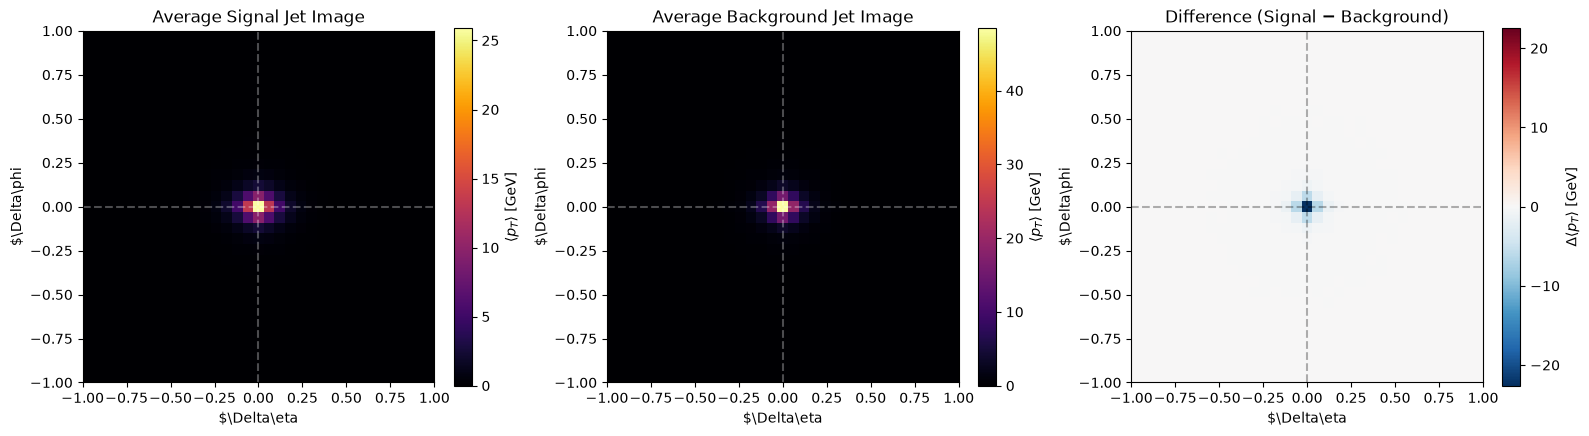

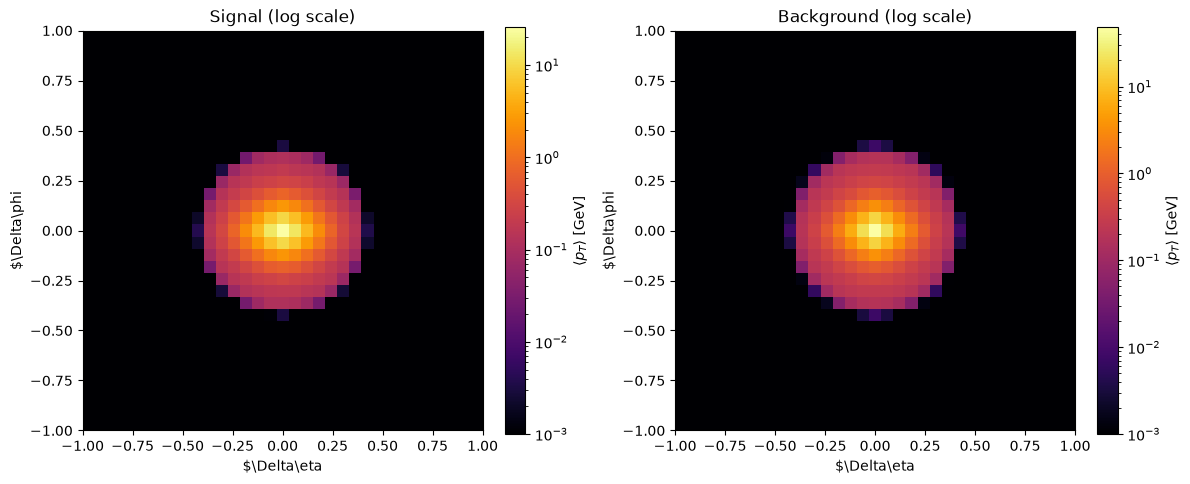

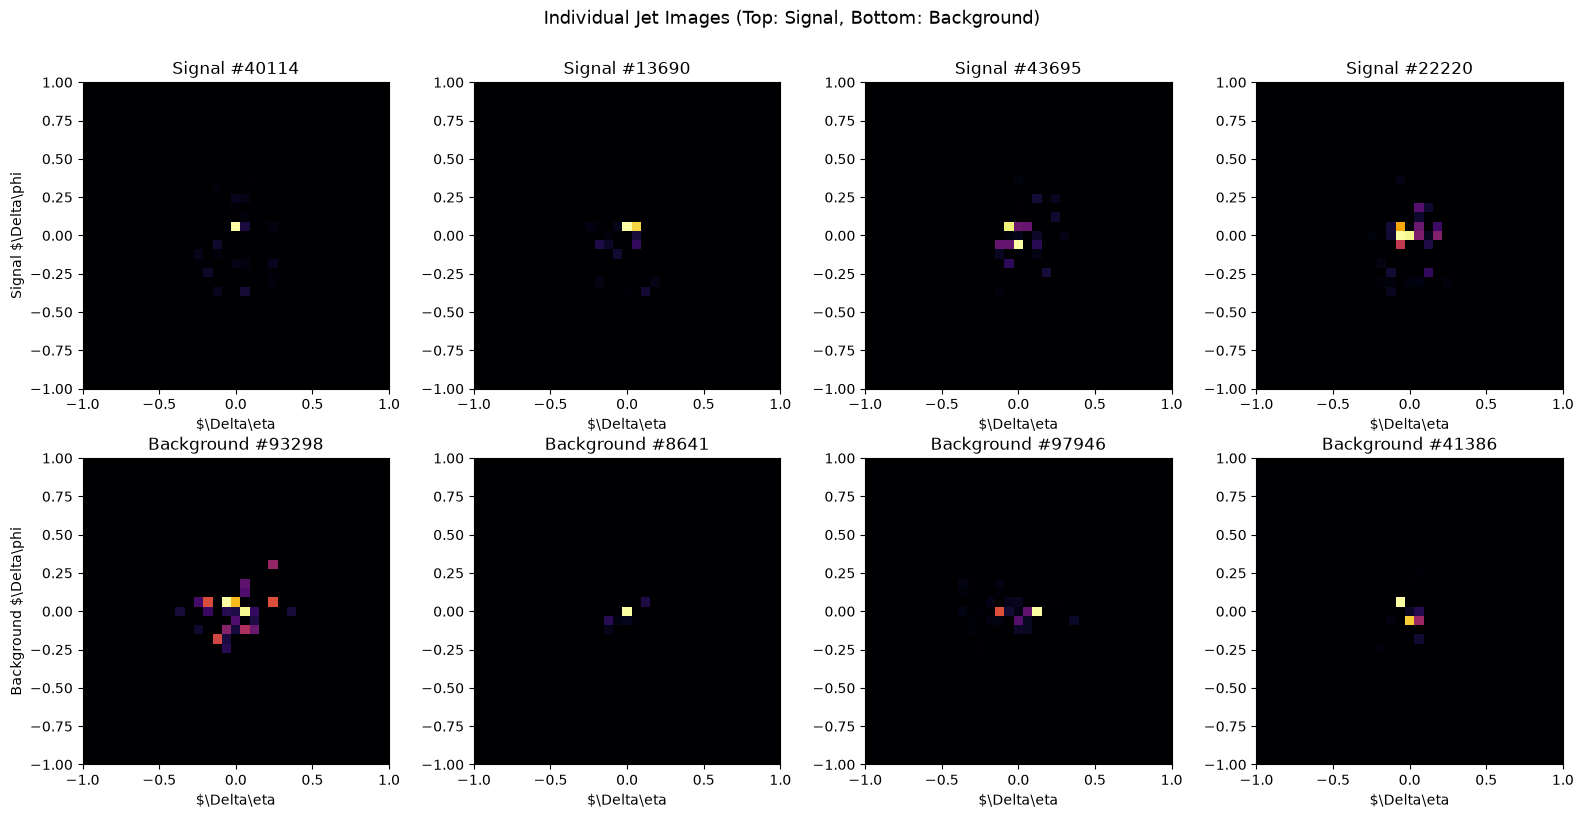

In [6]:
# ============================================================
# (CONTINUING FROM WHERE IT CUT OFF)
# ============================================================
# Assuming we already have:
#   sig_images : (N_sig, 33, 33) — signal jet images (pT-weighted, centered)
#   bkg_images : (N_bkg, 33, 33) — background jet images
#   ETA_RANGE = (-1.0, 1.0)
#   PHI_RANGE = (-1.0, 1.0)
#   N_PIXELS = 33

# ============================================================
# 4. VISUALIZATION — AVERAGE JET IMAGES
# ============================================================

# --- 4a. Average Signal vs Background ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average signal image
avg_sig = sig_images.mean(axis=0)                          # Average over all signal events
im0 = axes[0].imshow(
    avg_sig.T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='inferno', aspect='equal'
)
axes[0].set_xlabel(r'$\Delta\eta')
axes[0].set_ylabel(r'$\Delta\phi')
axes[0].set_title('Average Signal Jet Image')
axes[0].axhline(0, color='white', linestyle='--', alpha=0.3)
axes[0].axvline(0, color='white', linestyle='--', alpha=0.3)
plt.colorbar(im0, ax=axes[0], fraction=0.046, label=r'$\langle p_T \rangle$ [GeV]')

# Average background image
avg_bkg = bkg_images.mean(axis=0)                          # Average over all background events
im1 = axes[1].imshow(
    avg_bkg.T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='inferno', aspect='equal'
)
axes[1].set_xlabel(r'$\Delta\eta')
axes[1].set_ylabel(r'$\Delta\phi')
axes[1].set_title('Average Background Jet Image')
axes[1].axhline(0, color='white', linestyle='--', alpha=0.3)
axes[1].axvline(0, color='white', linestyle='--', alpha=0.3)
plt.colorbar(im1, ax=axes[1], fraction=0.046, label=r'$\langle p_T \rangle$ [GeV]')

# Difference image (Signal - Background)
diff_img = avg_sig - avg_bkg
max_abs = np.abs(diff_img).max()                           # Symmetric color scale
im2 = axes[2].imshow(
    diff_img.T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='RdBu_r', aspect='equal',
    vmin=-max_abs, vmax=max_abs                            # Centered at 0
)
axes[2].set_xlabel(r'$\Delta\eta')
axes[2].set_ylabel(r'$\Delta\phi')
axes[2].set_title('Difference (Signal − Background)')
axes[2].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[2].axvline(0, color='black', linestyle='--', alpha=0.3)
plt.colorbar(im2, ax=axes[2], fraction=0.046, label=r'$\Delta \langle p_T \rangle$ [GeV]')

plt.tight_layout()
plt.savefig('jet_images_average.pdf', bbox_inches='tight')
plt.show()

# --- 4b. Log-scale Average Images (better for seeing tails) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

from matplotlib.colors import LogNorm

# Set zero pixels to a small value for log scale
sig_log = avg_sig.copy()
sig_log[sig_log <= 0] = 1e-6
bkg_log = avg_bkg.copy()
bkg_log[bkg_log <= 0] = 1e-6

im0 = axes[0].imshow(
    sig_log.T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='inferno', aspect='equal',
    norm=LogNorm(vmin=1e-3, vmax=sig_log.max())
)
axes[0].set_xlabel(r'$\Delta\eta')
axes[0].set_ylabel(r'$\Delta\phi')
axes[0].set_title('Signal (log scale)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, label=r'$\langle p_T \rangle$ [GeV]')

im1 = axes[1].imshow(
    bkg_log.T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='inferno', aspect='equal',
    norm=LogNorm(vmin=1e-3, vmax=bkg_log.max())
)
axes[1].set_xlabel(r'$\Delta\eta')
axes[1].set_ylabel(r'$\Delta\phi')
axes[1].set_title('Background (log scale)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, label=r'$\langle p_T \rangle$ [GeV]')

plt.tight_layout()
plt.savefig('jet_images_average_logscale.pdf', bbox_inches='tight')
plt.show()

# --- 4c. Individual Events (4 signal, 4 background) ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Signal events (top row)
    idx = np.random.randint(0, len(sig_images))
    axes[0, i].imshow(
        sig_images[idx].T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='inferno', aspect='equal'
    )
    axes[0, i].set_title(f'Signal #{idx}')
    axes[0, i].set_xlabel(r'$\Delta\eta')
    if i == 0:
        axes[0, i].set_ylabel(r'Signal $\Delta\phi')

    # Background events (bottom row)
    idx = np.random.randint(0, len(bkg_images))
    axes[1, i].imshow(
        bkg_images[idx].T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='inferno', aspect='equal'
    )
    axes[1, i].set_title(f'Background #{idx}')
    axes[1, i].set_xlabel(r'$\Delta\eta')
    if i == 0:
        axes[1, i].set_ylabel(r'Background $\Delta\phi')

plt.suptitle('Individual Jet Images (Top: Signal, Bottom: Background)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('jet_images_individual.pdf', bbox_inches='tight')
plt.show()


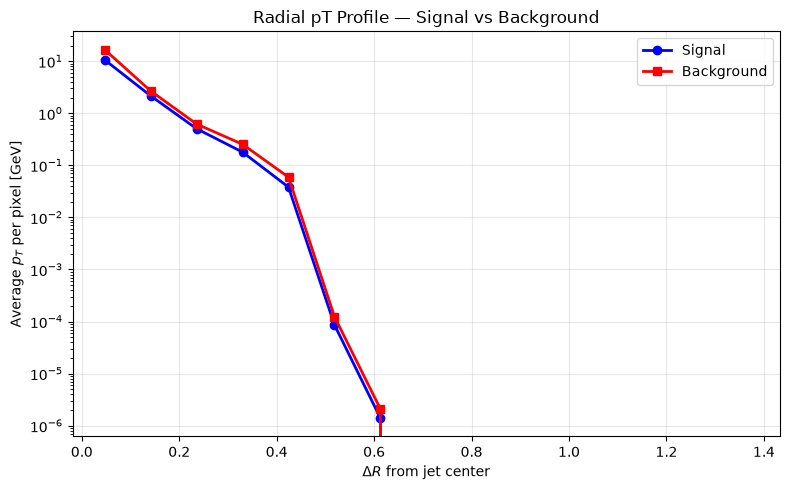

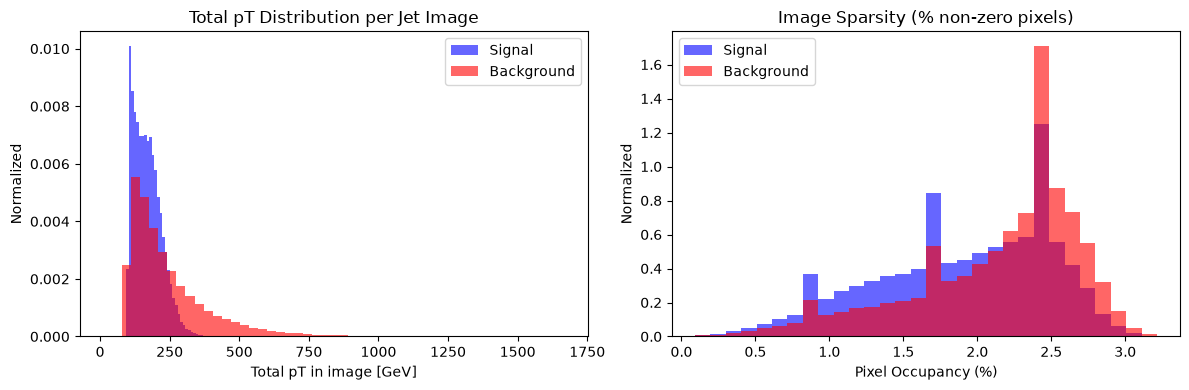

Signal: avg total pT = 169.1 GeV, avg occupancy = 1.9%
Background: avg total pT = 243.0 GeV, avg occupancy = 2.1%


In [7]:

# --- 4d. Radial pT Profile ---
def compute_radial_profile(images, eta_range, phi_range, n_bins=15):
    """Compute average pT as a function of ΔR from jet center."""
    n_pix = images.shape[1]
    eta_centers = np.linspace(eta_range[0], eta_range[1], n_pix)
    phi_centers = np.linspace(phi_range[0], phi_range[1], n_pix)
    eta_grid, phi_grid = np.meshgrid(eta_centers, phi_centers, indexing='ij')
    r_grid = np.sqrt(eta_grid**2 + phi_grid**2)            # ΔR from center
    
    r_bins = np.linspace(0, np.sqrt(eta_range[1]**2 + phi_range[1]**2), n_bins + 1)
    r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
    
    avg_image = images.mean(axis=0)                        # Average jet image
    profile = np.zeros(n_bins)
    for b in range(n_bins):
        ring = (r_grid >= r_bins[b]) & (r_grid < r_bins[b+1])
        if ring.sum() > 0:
            profile[b] = avg_image[ring].mean()
    
    return r_centers, profile

r_sig, prof_sig = compute_radial_profile(sig_images, ETA_RANGE, PHI_RANGE)
r_bkg, prof_bkg = compute_radial_profile(bkg_images, ETA_RANGE, PHI_RANGE)

plt.figure(figsize=(8, 5))
plt.plot(r_sig, prof_sig, 'b-o', lw=2, markersize=6, label='Signal')
plt.plot(r_bkg, prof_bkg, 'r-s', lw=2, markersize=6, label='Background')
plt.xlabel(r'$\Delta R$ from jet center')
plt.ylabel(r'Average $p_T$ per pixel [GeV]')
plt.title('Radial pT Profile — Signal vs Background')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('jet_images_radial_profile.pdf')
plt.show()

# --- 4e. Image Statistics ---
sig_total_pt = sig_images.sum(axis=(1, 2))                 # Total pT per image
bkg_total_pt = bkg_images.sum(axis=(1, 2))
sig_occupancy = (sig_images > 0).sum(axis=(1, 2)) / N_PIXELS**2 * 100
bkg_occupancy = (bkg_images > 0).sum(axis=(1, 2)) / N_PIXELS**2 * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(sig_total_pt, bins=50, alpha=0.6, density=True, label='Signal', color='blue')
ax1.hist(bkg_total_pt, bins=50, alpha=0.6, density=True, label='Background', color='red')
ax1.set_xlabel('Total pT in image [GeV]')
ax1.set_ylabel('Normalized')
ax1.set_title('Total pT Distribution per Jet Image')
ax1.legend()

ax2.hist(sig_occupancy, bins=30, alpha=0.6, density=True, label='Signal', color='blue')
ax2.hist(bkg_occupancy, bins=30, alpha=0.6, density=True, label='Background', color='red')
ax2.set_xlabel('Pixel Occupancy (%)')
ax2.set_ylabel('Normalized')
ax2.set_title('Image Sparsity (% non-zero pixels)')
ax2.legend()

plt.tight_layout()
plt.savefig('jet_images_statistics.pdf')
plt.show()

print(f"Signal: avg total pT = {sig_total_pt.mean():.1f} GeV, "
      f"avg occupancy = {sig_occupancy.mean():.1f}%")
print(f"Background: avg total pT = {bkg_total_pt.mean():.1f} GeV, "
      f"avg occupancy = {bkg_occupancy.mean():.1f}%")



In [9]:
# ============================================================
# 5. PREPARE DATA FOR CNN
# ============================================================
from sklearn.model_selection import train_test_split

# Combine signal and background
X_images = np.concatenate([sig_images, bkg_images], axis=0)  # (N_total, 33, 33)
y_labels = np.concatenate([
    np.ones(len(sig_images)),                              # Signal → 1
    np.zeros(len(bkg_images))                              # Background → 0
]).astype(np.float32)

print(f"\nTotal images: {X_images.shape}")
print(f"Signal: {int(y_labels.sum())}, Background: {int(len(y_labels) - y_labels.sum())}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_images, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Further split train → train/val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

print(f"Train: {X_tr.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# Normalize images: divide by max pixel value across training set
# This puts pixel intensities roughly in [0, 1]
max_pixel = X_tr.max()
X_tr_norm = X_tr / max_pixel
X_val_norm = X_val / max_pixel
X_test_norm = X_test / max_pixel

# Reshape for CNN: add channel dimension → (N, 1, H, W) for PyTorch
X_tr_cnn = X_tr_norm[:, np.newaxis, :, :].astype(np.float32)      # (N, 1, 33, 33)
X_val_cnn = X_val_norm[:, np.newaxis, :, :].astype(np.float32)
X_test_cnn = X_test_norm[:, np.newaxis, :, :].astype(np.float32)

print(f"CNN input shape: {X_tr_cnn.shape}")




Total images: (155025, 33, 33)
Signal: 45208, Background: 109817
Train: 105417, Val: 18603, Test: 31005
CNN input shape: (105417, 1, 33, 33)


In [10]:
# ============================================================
# 6. CNN MODEL DEFINITION (PyTorch)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cpu")
torch.manual_seed(42)


class JetImageCNN(nn.Module):
    """
    2D CNN for jet image classification.
    
    Architecture inspired by standard image classifiers,
    adapted for the small (33×33) sparse jet images.
    """
    def __init__(self, n_channels=1, n_pixels=33):
        super(JetImageCNN, self).__init__()
        
        # --- Convolutional feature extractor ---
        self.features = nn.Sequential(
            # Block 1: 1 → 32 channels
            nn.Conv2d(n_channels, 32, kernel_size=3, padding=1),   # (32, 33, 33)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),           # (32, 33, 33)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # (32, 16, 16)
            nn.Dropout2d(0.1),
            
            # Block 2: 32 → 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),           # (64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),           # (64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # (64, 8, 8)
            nn.Dropout2d(0.1),
            
            # Block 3: 64 → 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),          # (128, 8, 8)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),         # (128, 8, 8)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),                           # (128, 4, 4)
            nn.Dropout2d(0.2),
        )
        
        # --- Classification head ---
        self.classifier = nn.Sequential(
            nn.Flatten(),                                           # (128 * 4 * 4) = 2048
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()                                           # Binary probability
        )
    
    def forward(self, x):
        """
        x: (batch, 1, 33, 33) — single-channel jet image
        Returns: (batch, 1) — signal probability
        """
        x = self.features(x)                                       # Extract features
        x = self.classifier(x)                                     # Classify
        return x


# Instantiate
cnn_model = JetImageCNN(n_channels=1, n_pixels=N_PIXELS).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"\nJet Image CNN:")
print(f"  Input shape: (batch, 1, {N_PIXELS}, {N_PIXELS})")
print(f"  Total parameters: {total_params:,}")
print(cnn_model)




Jet Image CNN:
  Input shape: (batch, 1, 33, 33)
  Total parameters: 828,385
JetImageCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, 


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/envs/work_py_ml/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/work_py_ml/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/opt/anaconda3/envs/work_py_ml/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
    self.io_loop.sta

In [11]:
# ============================================================
# 7. TRAINING
# ============================================================

print("\n" + "=" * 60)
print("TRAINING JET IMAGE CNN")
print("=" * 60)

# Create DataLoaders
train_ds = TensorDataset(
    torch.FloatTensor(X_tr_cnn),
    torch.FloatTensor(y_tr).unsqueeze(1)
)
val_ds = TensorDataset(
    torch.FloatTensor(X_val_cnn),
    torch.FloatTensor(y_val).unsqueeze(1)
)
test_ds = TensorDataset(
    torch.FloatTensor(X_test_cnn),
    torch.FloatTensor(y_test).unsqueeze(1)
)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Training setup
criterion = nn.BCELoss()                                    # Binary cross-entropy
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)    # Adam optimizer
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

EPOCHS = 60
PATIENCE = 12
best_val_loss = float('inf')
patience_counter = 0
best_state = None

history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

for epoch in range(EPOCHS):
    # --- Training ---
    cnn_model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()                              # Clear gradients
        output = cnn_model(batch_X)                        # Forward pass
        loss = criterion(output, batch_y)                  # Compute loss
        loss.backward()                                    # Backprop
        torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        optimizer.step()                                   # Update weights
        train_loss += loss.item() * batch_X.size(0)
    train_loss /= len(train_ds)
    history['train_loss'].append(train_loss)
    
    # --- Validation ---
    cnn_model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels_list = []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            output = cnn_model(batch_X)
            loss = criterion(output, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            val_preds.append(output.numpy())
            val_labels_list.append(batch_y.numpy())
    
    val_loss /= len(val_ds)
    val_preds_arr = np.concatenate(val_preds).ravel()
    val_labels_arr = np.concatenate(val_labels_list).ravel()
    val_auc = roc_auc_score(val_labels_arr, val_preds_arr)
    
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    
    # LR scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in cnn_model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    if (epoch + 1) % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}: "
              f"train_loss={train_loss:.4f}, "
              f"val_loss={val_loss:.4f}, "
              f"val_auc={val_auc:.4f}, "
              f"lr={lr_now:.6f}")

# Restore best weights
cnn_model.load_state_dict(best_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")




TRAINING JET IMAGE CNN


KeyboardInterrupt: 

In [ ]:
# ============================================================
# 8. EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("EVALUATION ON TEST SET")
print("=" * 60)

cnn_model.eval()
all_preds = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        output = cnn_model(batch_X)
        all_preds.append(output.numpy())

y_prob = np.concatenate(all_preds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"\nJet Image CNN Results:")
print(f"  Accuracy: {acc:.4f}")
print(f"  AUC-ROC:  {auc:.4f}")

# Working points
print(f"\nWorking points:")
for threshold in [0.3, 0.5, 0.7, 0.9]:
    preds_wp = (y_prob >= threshold).astype(int)
    sig_eff = preds_wp[y_test == 1].mean()
    bkg_rej = 1.0 - preds_wp[y_test == 0].mean()
    print(f"  Threshold={threshold:.1f}: sig_eff={sig_eff:.4f}, bkg_rej={bkg_rej:.4f}")

# ============================================================
# 9. ROC CURVE
# ============================================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Standard ROC
ax1.plot(fpr, tpr, 'b-', lw=2, label=f'Jet Image CNN (AUC = {auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax1.set_xlabel('False Positive Rate (Background Efficiency)')
ax1.set_ylabel('True Positive Rate (Signal Efficiency)')
ax1.set_title('ROC Curve — Jet Image CNN')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Signal eff vs background rejection
bkg_rej = 1.0 / (fpr + 1e-10)
valid = fpr > 0
ax2.plot(tpr[valid], bkg_rej[valid], 'b-', lw=2)
ax2.set_xlabel('Signal Efficiency')
ax2.set_ylabel('Background Rejection (1/FPR)')
ax2.set_yscale('log')
ax2.set_xlim([0, 1])
ax2.set_ylim([1, 1e4])
ax2.set_title('Signal Efficiency vs Background Rejection')
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('roc_jet_image_cnn.pdf')
plt.show()

# ============================================================
# 10. TRAINING CURVES
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['val_auc'], label='Val AUC', color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('Validation AUC'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('jet_image_cnn_training.pdf')
plt.show()



In [ ]:
# ============================================================
# 11. CNN FILTER VISUALIZATION
# ============================================================
# What patterns has the first convolutional layer learned?

print("\n" + "=" * 60)
print("CNN FILTER VISUALIZATION")
print("=" * 60)

# Extract first conv layer weights
first_conv_weights = cnn_model.features[0].weight.detach().numpy()  # (32, 1, 3, 3)
n_filters = first_conv_weights.shape[0]

# Plot first 16 filters
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    if i < n_filters:
        filt = first_conv_weights[i, 0]                    # (3, 3) filter
        im = ax.imshow(filt, cmap='RdBu_r', aspect='equal',
                       vmin=-np.abs(filt).max(), vmax=np.abs(filt).max())
        ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')
plt.suptitle('First Conv Layer Learned Filters (3×3)', fontsize=13)
plt.tight_layout()
plt.savefig('cnn_filters_layer1.pdf')
plt.show()

# ============================================================
# 12. ACTIVATION MAP VISUALIZATION (Grad-CAM style)
# ============================================================
# Show which regions of the jet image the CNN focuses on

def get_activation_maps(model, image_tensor):
    """
    Get activation maps from the last conv layer for a single image.
    
    Parameters:
    -----------
    model : JetImageCNN
    image_tensor : (1, 1, 33, 33)
    
    Returns:
    --------
    activation_map : (H, W) — averaged over channels, upsampled to input size
    """
    model.eval()
    activations = {}
    
    # Hook to capture activations
    def hook_fn(module, input, output):
        activations['last_conv'] = output.detach()
    
    # Register hook on last conv layer (Block 3, second Conv2d)
    # features[14] is the last Conv2d before AdaptiveAvgPool
    hook = model.features[14].register_forward_hook(hook_fn)
    
    with torch.no_grad():
        _ = model(image_tensor)
    
    hook.remove()
    
    # Average over channels
    act_map = activations['last_conv'].squeeze().numpy()    # (128, H, W)
    avg_map = act_map.mean(axis=0)                         # (H, W)
    
    # Upsample to input size using simple interpolation
    from scipy.ndimage import zoom
    scale_h = N_PIXELS / avg_map.shape[0]
    scale_w = N_PIXELS / avg_map.shape[1]
    upsampled = zoom(avg_map, (scale_h, scale_w), order=1)
    
    # Normalize to [0, 1]
    upsampled = (upsampled - upsampled.min()) / (upsampled.max() - upsampled.min() + 1e-10)
    
    return upsampled


# Visualize activation maps for a few events
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col in range(4):
    # Pick a signal event
    sig_idx = np.where(y_test == 1)[0][col]
    img_tensor = torch.FloatTensor(X_test_cnn[sig_idx:sig_idx+1])
    act_map = get_activation_maps(cnn_model, img_tensor)
    
    # Original image
    axes[0, col].imshow(
        X_test_cnn[sig_idx, 0].T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='inferno', aspect='equal'
    )
    axes[0, col].set_title(f'Signal #{sig_idx}\np={y_prob[sig_idx]:.3f}')
    axes[0, col].set_xlabel(r'$\Delta\eta')
    if col == 0:
        axes[0, col].set_ylabel(r'$\Delta\phi')
    
    # Activation overlay
    axes[1, col].imshow(
        X_test_cnn[sig_idx, 0].T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='gray', aspect='equal', alpha=0.5
    )
    axes[1, col].imshow(
        act_map.T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='jet', aspect='equal', alpha=0.5
    )
    axes[1, col].set_xlabel(r'$\Delta\eta')
    if col == 0:
        axes[1, col].set_ylabel(r'$\Delta\phi')

plt.suptitle('CNN Attention: Where the model looks\n'
             '(Top: original image, Bottom: activation overlay)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('cnn_activation_maps.pdf', bbox_inches='tight')
plt.show()

# ============================================================
# 13. OUTPUT SCORE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

sig_scores = y_prob[y_test == 1]
bkg_scores = y_prob[y_test == 0]

ax.hist(sig_scores, bins=50, alpha=0.6, density=True, label='Signal', color='blue')
ax.hist(bkg_scores, bins=50, alpha=0.6, density=True, label='Background', color='red')
ax.axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
ax.set_xlabel('CNN Output Score')
ax.set_ylabel('Normalized Distribution')
ax.set_title('Jet Image CNN — Discriminant Output')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_output_distribution.pdf')
plt.show()

# ============================================================
# 14. MISCLASSIFIED EVENTS
# ============================================================
# Look at what the model gets wrong

# Signal events classified as background (false negatives)
fn_mask = (y_test == 1) & (y_pred == 0)
# Background events classified as signal (false positives)
fp_mask = (y_test == 0) & (y_pred == 1)

print(f"\nMisclassified events:")
print(f"  False negatives (missed signal): {fn_mask.sum()}")
print(f"  False positives (fake signal):   {fp_mask.sum()}")

if fn_mask.sum() > 0 and fp_mask.sum() > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    fn_indices = np.where(fn_mask)[0][:4]
    fp_indices = np.where(fp_mask)[0][:4]
    
    for i, idx in enumerate(fn_indices):
        axes[0, i].imshow(
            X_test_cnn[idx, 0].T, origin='lower',
            extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
            cmap='inferno', aspect='equal'
        )
        axes[0, i].set_title(f'FN: score={y_prob[idx]:.3f}')
        axes[0, i].set_xlabel(r'$\Delta\eta')
        if i == 0:
            axes[0, i].set_ylabel('Missed Signal\n' + r'$\Delta\phi')

    for i, idx in enumerate(fp_indices):
        axes[1, i].imshow(
            X_test_cnn[idx, 0].T, origin='lower',
            extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
            cmap='inferno', aspect='equal'
        )
        axes[1, i].set_title(f'FP: score={y_prob[idx]:.3f}')
        axes[1, i].set_xlabel(r'$\Delta\eta')
        if i == 0:
            axes[1, i].set_ylabel('Fake Signal\n' + r'$\Delta\phi')

    plt.suptitle('Misclassified Events\n'
                 '(Top: signal misclassified as background, '
                 'Bottom: background misclassified as signal)',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('cnn_misclassified.pdf', bbox_inches='tight')
    plt.show()

print("\nDone! All plots saved.")